## Library import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Reading Data

In [5]:
df = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx")
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


### Reading all Excel Sheet.

In [6]:
file_path = "C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx"
fil = pd.ExcelFile(file_path)
print(fil.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## Defining Sheets in Variable for merging.

In [7]:
df_demo = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx",sheet_name="Customer_Demographics")

In [8]:
df_trans = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name="Transaction_History")

In [9]:
df_service = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Customer_Service")

In [10]:
df_online = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Online_Activity")

In [11]:
df_churn = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Churn_Status")

### Merging sheets.

In [12]:
df_merged = pd.merge(df_demo, df_trans, on = 'CustomerID')

In [13]:
df_merged = pd.merge(df_merged, df_service, on = 'CustomerID')

In [14]:
df_merged = pd.merge(df_merged, df_online, on = 'CustomerID')

In [15]:
df_finall = pd.merge(df_merged, df_churn, on = 'CustomerID')

In [16]:
df_finall.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


## Data quality checking.

In [17]:
df_finall.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [18]:
df_finall.info()

<class 'pandas.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   str           
 3   MaritalStatus     5204 non-null   str           
 4   IncomeLevel       5204 non-null   str           
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[us]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   str           
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[us]
 11  InteractionType   5204 non-null   str           
 12  ResolutionStatus  5204 non-null   str           
 13  LastLoginDate     5204 non-null   datetime64[us]
 14  LoginFrequency    5204 non-null   i

In [19]:
df_finall.shape

(5204, 17)

### Rought estimation of age max min value.

In [20]:
df_finall['Age'].max()  # finding max age

np.int64(69)

In [21]:
df_finall['Age'].min() # finding min age

np.int64(18)

### Histogram for identifying customer age group and frequency.

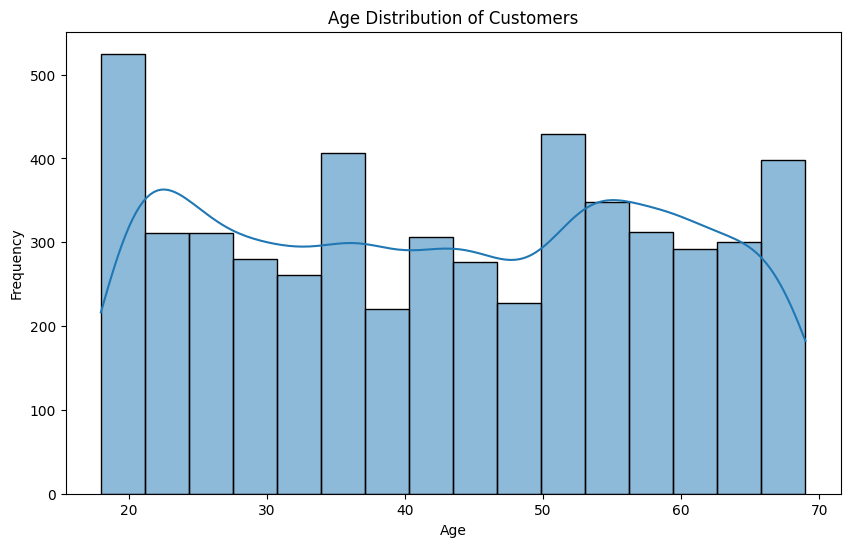

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df_finall, x = 'Age', kde = True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Finding outliers in age and plot it on box plot.

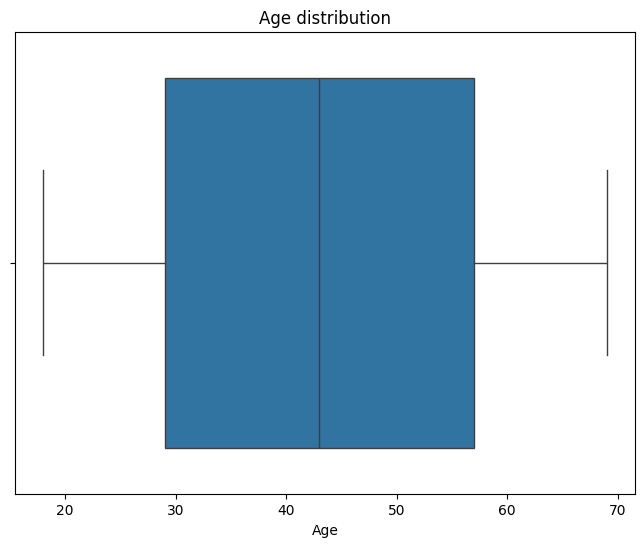

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(df_finall, x = 'Age')
plt.title('Age distribution')
plt.xlabel('Age')
plt.show()

### Droping unnecessary columns.

In [24]:
drop_columns = ['CustomerID', 'TransactionID', 'InteractionID']
df_finall = df_finall.drop(columns = drop_columns)
print(df_finall.columns)

Index(['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'TransactionDate',
       'AmountSpent', 'ProductCategory', 'InteractionDate', 'InteractionType',
       'ResolutionStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage',
       'ChurnStatus'],
      dtype='str')


### Finding correlation between customer churn and its other factor.

In [25]:
# creating variable for storing only numeric value for finding correlation
numeric_df = df_finall.select_dtypes(include = ['number','float', 'int'])

In [26]:
cor_matrix = numeric_df.corr() # finding correlation of numeric column in dataframe.
cor_matrix

,Age,AmountSpent,LoginFrequency,ChurnStatus
Age,1.000000,0.008364,-0.008731,0.036734
AmountSpent,0.008364,1.000000,0.034658,-0.000230
LoginFrequency,-0.008731,0.034658,1.000000,-0.096564
ChurnStatus,0.036734,-0.000230,-0.096564,1.000000


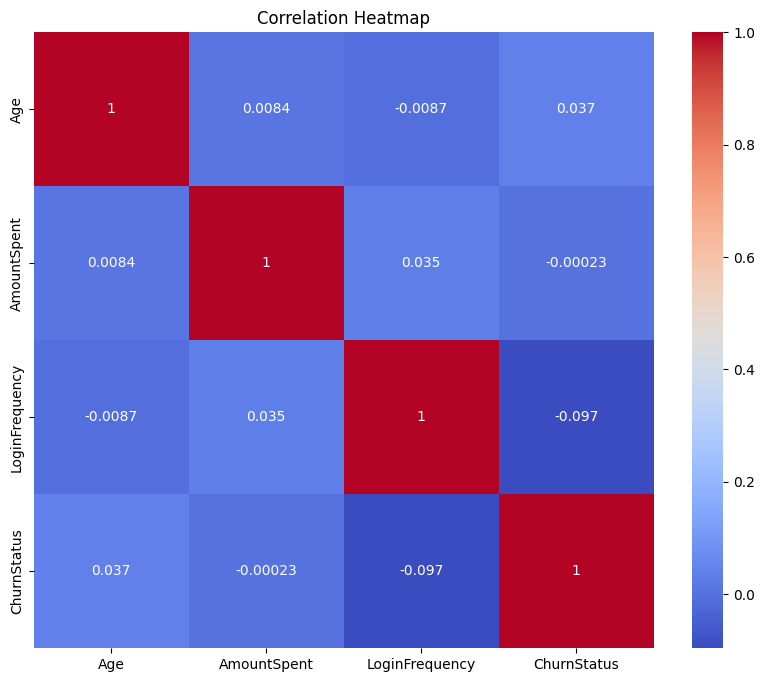

In [27]:
# ploting correlation on heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cor_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
df_finall.head()

,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,62,M,Single,Low,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,65,M,Married,Low,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,65,M,Married,Low,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,65,M,Married,Low,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,65,M,Married,Low,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


### Encoding columns

In [29]:
encoding_columns = ['MaritalStatus','IncomeLevel','Gender','ProductCategory','InteractionType','ResolutionStatus','ServiceUsage'] # creating list of column for encoding them.

In [30]:
df_encoded = pd.get_dummies(df_finall, columns = encoding_columns, drop_first = True,dtype = int)

In [31]:
df_encoded.head()

,Age,TransactionDate,AmountSpent,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,...,Gender_M,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,62,2022-03-27,416.50,2022-03-31,2023-10-21,34,0,0,1,0,...,1,0,1,0,0,0,1,0,0,0
1,65,2022-08-08,54.96,2022-03-17,2023-12-05,5,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1
2,65,2022-07-25,197.50,2022-03-17,2023-12-05,5,1,1,0,0,...,1,0,1,0,0,0,1,0,0,1
3,65,2022-01-25,101.31,2022-03-17,2023-12-05,5,1,1,0,0,...,1,0,0,1,0,0,1,0,0,1
4,65,2022-07-24,397.37,2022-03-17,2023-12-05,5,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1


In [ ]:
df_encoded['TransactionMonth'] = pd.to_datetime(df_encoded['TransactionDate'], errors = 'coerce').dt.month  # Month extracted from TransactionDate column in  anew column.

In [ ]:
df_encoded = df_encoded.drop(columns = 'TransactionDate')    # TransactionDate column droped

In [34]:
df_encoded['TransactionMonth']

0        3
1        8
2        7
3        1
4        7
        ..
5199     3
5200     8
5201    10
5202    10
5203    12
Name: TransactionMonth, Length: 5204, dtype: int32

In [38]:
df_encoded['InteractionMonth'] = pd.to_datetime(df_encoded['InteractionDate'], errors = 'coerce').dt.month  # extracting month from interaction date column in a new column.
df_encoded['LastLoginMonth'] = pd.to_datetime(df_encoded['LastLoginDate'], errors = 'coerce').dt.month  # extracting monnth from Last Login date column.

In [39]:
df_encoded = df_encoded.drop(columns = 'InteractionDate')  # InteractionDate column droped
df_encoded = df_encoded.drop(columns = 'LastLoginDate')   # LastLoginDate column droped

In [40]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          5204 non-null   int64  
 1   AmountSpent                  5204 non-null   float64
 2   LoginFrequency               5204 non-null   int64  
 3   ChurnStatus                  5204 non-null   int64  
 4   MaritalStatus_Married        5204 non-null   int64  
 5   MaritalStatus_Single         5204 non-null   int64  
 6   MaritalStatus_Widowed        5204 non-null   int64  
 7   IncomeLevel_Low              5204 non-null   int64  
 8   IncomeLevel_Medium           5204 non-null   int64  
 9   Gender_M                     5204 non-null   int64  
 10  ProductCategory_Clothing     5204 non-null   int64  
 11  ProductCategory_Electronics  5204 non-null   int64  
 12  ProductCategory_Furniture    5204 non-null   int64  
 13  ProductCategory_Groceries    

### Spliting data in X & y variable by train test split.

In [41]:
X = df_encoded.drop('ChurnStatus', axis = 1)  # independent variable

In [42]:
y = df_encoded['ChurnStatus']  # dependent variable

### Checking for variable data shape

In [44]:
X.shape

(5204, 21)

In [45]:
y.shape

(5204,)

### Data definig in train test split and hiding data for test.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # dividing data into train and test set with 80% and 20% respectively.